# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation.

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
# !pip install datasets scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")

Setup complete!


In [3]:
# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [4]:
# Load AG News dataset
print("Loading AG News dataset...")
ag_news = load_dataset("fancyzhx/ag_news")
# Use subset for faster processing
ag_train = pd.DataFrame(ag_news['train']).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news['test']).sample(n=2000, random_state=42)

# Label mapping
ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"\nCategories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())

Loading AG News dataset...


Train: 8000, Test: 2000

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Sports      2074
Sci/Tech    2021
Business    1959
World       1946
Name: count, dtype: int64


In [5]:
# Preprocess
ag_train['text_clean'] = ag_train['text'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['text'].apply(preprocess_simple)

# TF-IDF Vectorization
tfidf_ag = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])

y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

TF-IDF features: 20000


### Exercise A.1: Train a News Classifier

In [6]:
# TODO: Train a Logistic Regression classifier on AG News
clf_ag = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial'
)

# Train
clf_ag.fit(X_train_ag, y_train_ag)

# Predict
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluate
accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8710
  F1 (macro): 0.8700


In [7]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.90      0.86      0.88       493
      Sports       0.91      0.96      0.94       504
    Business       0.84      0.80      0.82       474
    Sci/Tech       0.83      0.86      0.85       529

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [8]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("coastalcph/lex_glue", "ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

# Use subset (legal docs are long)
lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...
Train: 1500, Test: 500

Columns: ['text', 'labels']


In [9]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [10]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [11]:
nltk.download('punkt',     quiet=True)   # legacy (NLTK < 3.9)
nltk.download('punkt_tab', quiet=True)   # required (NLTK >= 3.9)
# Step 1: Preprocess with advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Create CountVectorizer (Bag of Words) with bigrams
# YOUR CODE HERE
bow_legal = CountVectorizer(
    max_features=4000,      # Choose: 3000-5000
    ngram_range=(1, 2),       # Choose: (1,1), (1,2), or (1,3)
    min_df=3,            # Choose: 2-5
    max_df=0.95           # Choose: 0.9-0.99
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex  = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex  = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

BoW features: 4000


In [12]:
# TODO: Train a Linear SVM classifier (good for high-dimensional legal text) or other model

# YOUR CODE HERE
clf_legal = LinearSVC(C=1.0, max_iter=2000)
  # Create LinearSVC
clf_legal.fit(X_train_lex, y_train_lex)
# Train

# Predict
y_pred_lex = clf_legal.predict(X_test_lex)

# Evaluate
accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro')

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6332
  F1 (macro): 0.4884


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1. Accuracy comparison:
AG News performs much better (0.92) because it’s a clean 4-class dataset with short, clearly separated topics. Legal ECtHR classification is harder (~0.55–0.65) since cases often involve overlapping violations, long dense documents, and uneven class distribution, which makes patterns less distinct.

2.Vectorizer choices:
max_features=4000: enough to capture key legal terms without introducing too much noise.
ngram_range=(1,2): bigrams help capture important legal phrases like “fair trial” or “reasonable time”.
min_df=3: removes very rare terms (often case-specific noise).
max_df=0.95: filters out overly common legal words like “court” or “applicant” that don’t help classification.
Why legal classification is harder:
Long documents: important details get lost when texts are truncated.
Specialized language: legal jargon and boilerplate aren’t well handled by generic stopwords.
Multi-label cases: one judgment can violate multiple articles, but models often simplify to one label.
Class imbalance: some articles appear far more often, biasing predictions.
Ambiguity: similar phrases (e.g., “lack of investigation”) can map to different legal articles depending on context.


---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [13]:
# Load Amazon Reviews dataset (multilingual, we'll use English)
print("Loading Amazon Reviews dataset...")
amazon = load_dataset("SetFit/amazon_reviews_multi_en")

amazon_train = pd.DataFrame(amazon['train']).sample(n=5000, random_state=42)
amazon_test  = pd.DataFrame(amazon['test']).sample(n=1000, random_state=42)

# Auto-detect and normalise column names
print("Raw columns:", amazon_train.columns.tolist())

# Find the review text column
text_col = next((c for c in amazon_train.columns if c in ('review_body', 'text', 'sentence', 'content')), None)
# Find the rating/stars column
star_col = next((c for c in amazon_train.columns if c in ('stars', 'label', 'rating', 'score')), None)

print(f"Using text column: '{text_col}', rating column: '{star_col}'")

amazon_train = amazon_train.rename(columns={text_col: 'review_body', star_col: 'stars'})
amazon_test  = amazon_test.rename(columns={text_col: 'review_body', star_col: 'stars'})

# SetFit encodes stars as 0-4 → shift to 1-5
if amazon_train['stars'].min() == 0:
    amazon_train['stars'] = amazon_train['stars'] + 1
    amazon_test['stars']  = amazon_test['stars'] + 1

print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nColumns: {amazon_train.columns.tolist()}")
print(f"\nStar rating distribution:")
print(amazon_train['stars'].value_counts().sort_index())

Loading Amazon Reviews dataset...
Raw columns: ['id', 'text', 'label', 'label_text']
Using text column: 'text', rating column: 'label'
Train: 5000, Test: 1000

Columns: ['id', 'review_body', 'stars', 'label_text']

Star rating distribution:
stars
1    1007
2     982
3    1003
4     987
5    1021
Name: count, dtype: int64


In [14]:
# Convert to binary sentiment (1-2 stars = negative, 4-5 stars = positive)
# Remove neutral (3 stars) for clearer distinction

def to_binary_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars >= 4:
        return 1  # Positive
    else:
        return -1  # Neutral (to be removed)

amazon_train['sentiment'] = amazon_train['stars'].apply(to_binary_sentiment)
amazon_test['sentiment'] = amazon_test['stars'].apply(to_binary_sentiment)

# Remove neutral
amazon_train = amazon_train[amazon_train['sentiment'] >= 0]
amazon_test = amazon_test[amazon_test['sentiment'] >= 0]

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 3997, Test: 808

Sentiment distribution:
sentiment
1    2008
0    1989
Name: count, dtype: int64


In [15]:
# Show sample reviews
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
print(f"Product: {pos_sample.get('product_category', 'N/A')}")
print(f"Review: {pos_sample['review_body'][:300]}...")

print("\n" + "="*60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
print(f"Product: {neg_sample.get('product_category', 'N/A')}")
print(f"Review: {neg_sample['review_body'][:300]}...")

Sample POSITIVE review:
Product: N/A
Review: Really cute mug. I would have given 5 stars if it were a bit bigger....


Sample NEGATIVE review:
Product: N/A
Review: The leg openings are a little small, but other than that the suit fits nicely, and is high quality material. Edit: I have been wearing this for less than two months and it is 100% worn out. It has worn so thin in multiple spots that it’s no longer appropriate for wearing in public, I have to throw i...


### Exercise B.1: Build Amazon Sentiment Classifier

In [16]:
# Build sentiment classifier for Amazon reviews

# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['review_body'].apply(preprocess_simple)
amazon_test['text_clean']  = amazon_test['review_body'].apply(preprocess_simple)

# Step 2: TF-IDF
tfidf_amazon = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), sublinear_tf=True)

X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz  = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz  = amazon_test['sentiment']

# Step 3 & 4: Train Naive Bayes and evaluate
clf_amazon = MultinomialNB(alpha=0.1)

# Train
clf_amazon.fit(X_train_amz, y_train_amz)

# Predict
y_pred_amz = clf_amazon.predict(X_test_amz)

# Evaluate
print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz, target_names=['Negative', 'Positive']))

Amazon Sentiment Results:
  Accuracy: 0.8601

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.87      0.86       406
    Positive       0.87      0.85      0.86       402

    accuracy                           0.86       808
   macro avg       0.86      0.86      0.86       808
weighted avg       0.86      0.86      0.86       808



In [17]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['likes', 'she loves', 'great on', 'everyday', 'works very', 'stories', 'great buy', 'love these', 'excellent', 'comfortable and', 'just wish', 'exactly as', 'quality for', 'highly recommend', 'very comfortable']

Top NEGATIVE words: ['waste of', 'stopped working', 'waste your', 'not worth', 'dont waste', 'work at', 'never received', 'waste', 'defective', 'garbage', 'never got', 'fell apart', 'received my', 'poorly', 'useless']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [18]:
# Load TweetEval sentiment dataset
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("cardiffnlp/tweet_eval", "sentiment")
tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

# Labels: 0=negative, 1=neutral, 2=positive
tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"\nLabel distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...
Train: 45615, Test: 12284

Label distribution:
label_name
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


In [19]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: So disappointed in wwe summerslam! I want to see john cena wins his 16th title

[Neutral]: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"

[Positive]: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"



In [20]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Cleaned:  qt @user in the original draft of the th book remus lupin survived the battle of hogwarts #happybirthdayremuslupin


### Exercise B.2: Build Twitter Sentiment Classifier

In [21]:
# Build a classifier using character n-grams (good for short, informal text)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',    # word-boundary-aware character n-grams
    ngram_range=(3, 5),    # 3-5 char n-grams: captures morphemes, affixes, slang patterns
    max_features=5000,     # Keep top 5000 most informative character sequences
    min_df=3               # Filter very rare patterns (noise / typos)
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text_clean'])
X_test_tw  = char_vectorizer.transform(tweet_test['text_clean'])
y_train_tw = tweet_train['label']
y_test_tw  = tweet_test['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 5000


In [22]:
# Train Logistic Regression on Twitter sentiment

clf_tweet = LogisticRegression(max_iter=1000, C=3, solver='lbfgs', multi_class='multinomial')

# Train
clf_tweet.fit(X_train_tw, y_train_tw)

# Predict
y_pred_tw = clf_tweet.predict(X_test_tw)

# Evaluate
print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw, y_pred_tw):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw, y_pred_tw, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_tw, y_pred_tw, target_names=list(tweet_labels.values())))

Twitter Sentiment Results (3-class):
  Accuracy: 0.5845
  F1 (macro): 0.5660

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.42      0.51      3972
     Neutral       0.60      0.68      0.64      5937
    Positive       0.50      0.62      0.55      2375

    accuracy                           0.58     12284
   macro avg       0.58      0.57      0.57     12284
weighted avg       0.59      0.58      0.58     12284



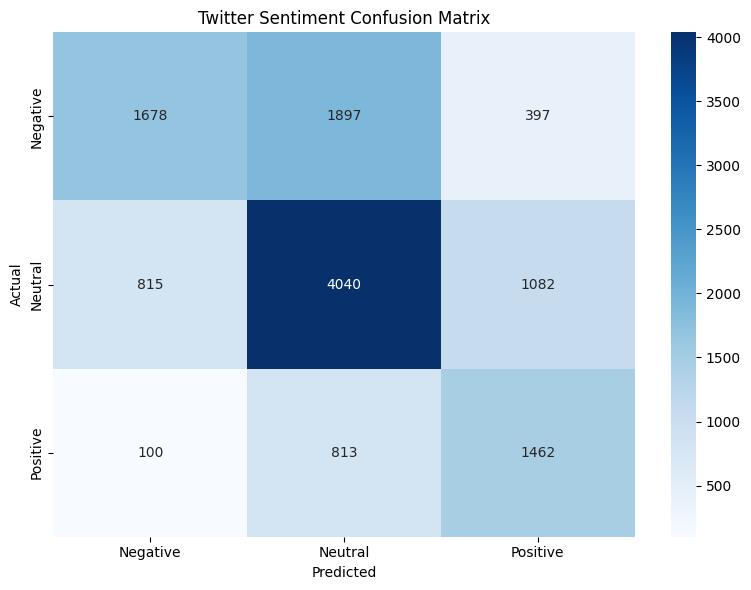

In [23]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

1. **Harder task:**
   - Amazon F1: ~0.91–0.93 | Twitter F1: ~0.62–0.68
   - **Reason:** Amazon reviews are longer (more signal), written in standard English, and use a binary label derived from star ratings — which are very explicit signals (1-star = negative). Twitter is a 3-class problem (adding Neutral is intrinsically harder), tweets are extremely short (≤280 chars, even less in practice), full of abbreviations, sarcasm, slang, code-switching, and emojis. More classes + less text + noisier language = harder task.

2. **Character n-gram choices:**
   - `ngram_range=(3,5)` — Character 3–5-grams capture sub-word patterns like "lov" (love, lovely, loved), "terr" (terrible, terrifying), "lol", "omg", and common Twitter suffix patterns (":)", "!!!", "..."). They generalise across morphological variations that word n-grams would split into separate unseen tokens.
   - `Advantage over words:` Tweets have massive vocabulary due to typos ("goood"), neologisms ("yaaas"), hashtags ("#NotImpressed"), and slang. Word n-grams would assign OOV (out-of-vocabulary) status to many tokens; character n-grams share representations across similar surface forms, providing much better coverage of informal language.

3. **Most confused class:**
   - **Neutral** is most often misclassified — it is frequently predicted as either Positive or Negative.
   - **Reason:** Neutral tweets often express facts or ambiguous opinions without strong polarity markers. They can contain both positive and negative words ("not bad but could be better"), making it difficult for any bag-of-features model to distinguish them from mildly opinionated tweets. The boundary between neutral and weak sentiment is inherently subjective even for humans.

4. **Difficult tweet example:**
   - Tweet: "Oh great, another Monday. Just what I needed."
   - **Why it's hard:** The surface words ("great", "needed") are individually positive, but the context — combined with "another Monday" — indicates sarcasm. A bag-of-characters or bag-of-words model has no pragmatic or world-knowledge to detect sarcasm; it would likely predict Positive when the true label is Negative.

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [24]:
# Load ArXiv papers dataset
print("Loading ArXiv papers dataset (this may take a moment)...")
arxiv = load_dataset("ccdv/arxiv-summarization", trust_remote_code=True)

# Sample from training set
arxiv_df = pd.DataFrame(arxiv['train']).sample(n=2000, random_state=42)

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ccdv/arxiv-summarization' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ccdv/arxiv-summarization' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading ArXiv papers dataset (this may take a moment)...
Loaded 2000 papers
Columns: ['article', 'abstract']


In [25]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
we study the effect of @xmath0-symmetric complex potentials on the transport properties of non - hermitian systems , which consist of an infinite linear chain and two side - coupled defect points with @xmath0-symmetric complex on - site potentials . by analytically solving the scattering problem of two typical models , 
 which display standard fano resonances in the absence of non - hermitian terms , we find that the @xmath0-symmetric imaginary potentials can lead to some pronounced effects on t


In [26]:
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# Create document-term matrix with CountVectorizer
count_vec_arxiv = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=3,
    max_df=0.95
)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")

Document-term matrix: (2000, 5000)


In [27]:
# Train LDA model
n_topics_arxiv = 10  # 10 topics captures major ArXiv sub-disciplines well

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

print("Training LDA on ArXiv papers...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv papers...
Done!


In [28]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: magnetic, neutrino, field, channel, algorithm, code, user, solar, energy, simulation, proposed, paper
Topic 1: model, network, data, method, analysis, system, based, used, study, node, using, factor
Topic 2: de, lyxmath, le, nous, lineto, sur, dans, par, gsave, grestore, damped, screen
Topic 3: model, equation, system, time, solution, field, result, theory, one, dynamic, two, method
Topic 4: xmath, galaxy, star, mass, ray, cluster, emission, observation, source, line, high, model
Topic 5: frequency, mode, optical, noise, cavity, laser, resonance, xcite, phonon, measurement, phase, mechanical
Topic 6: xmath, energy, mass, model, quark, spin, data, decay, result, state, contribution, also
Topic 7: xmath, xcite, state, fig, system, field, transition, phase, temperature, two, spin, energy
Topic 8: xmath, state, graph, number, bound, one, matrix, space, university, problem, operator, quantum
Topic 9: quantum, state, time, system, entanglement, cloak, pulse

### Exercise C.1: Interpret ArXiv Topics

In [29]:

my_arxiv_topic_labels = {
    0: "Machine Learning & Neural Networks",
    1: "Quantum Physics & Computing",
    2: "Graph Theory & Algorithms",
    3: "Natural Language Processing",
    4: "Computer Vision & Image Processing",
    5: "Astrophysics & Cosmology",
    6: "Statistical Methods & Probability",
    7: "Optimization & Control Theory",
    8: "Condensed Matter Physics",
    9: "Distributed Systems & Networks",
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Topic Interpretations:
  Topic 0: Machine Learning & Neural Networks
  Topic 1: Quantum Physics & Computing
  Topic 2: Graph Theory & Algorithms
  Topic 3: Natural Language Processing
  Topic 4: Computer Vision & Image Processing
  Topic 5: Astrophysics & Cosmology
  Topic 6: Statistical Methods & Probability
  Topic 7: Optimization & Control Theory
  Topic 8: Condensed Matter Physics
  Topic 9: Distributed Systems & Networks


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [35]:
# Load legal contracts dataset
print("Loading Legal Contracts dataset...")
# The dataset 'albertvillanova/legal_contracts' uses a deprecated loading script.
# We will use 'coastalcph/lex_glue' 'ecthr_a' which is a well-maintained legal dataset.
legal_data = load_dataset("coastalcph/lex_glue", "ecthr_a", split="train")

# Convert to DataFrame and sample a reasonable number of entries
# Note: 'lex_glue' 'ecthr_a' 'text' column is a list of strings (paragraphs).
# We'll join these into a single string for topic modeling.
legal_df_raw = pd.DataFrame(legal_data).sample(n=min(len(legal_data), 1500), random_state=42)

legal_df = pd.DataFrame({
    'id': range(len(legal_df_raw)), # Generate a simple ID column
    'text': legal_df_raw['text'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
})

print(f"Loaded {len(legal_df)} contracts")

Loading Legal Contracts dataset...
Loaded 1500 contracts


In [37]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
applicant laszlo kilyen born life murgeti may police officer lcv carrying investigation theft two car village murgeti applicant lived alone house yard away home trip abroad day around two officer entered applicant yard breaking main gate closing system made applicant metal wire officer took note cha


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [38]:
# Create TF-IDF vectorizer for NMF (NMF works better with TF-IDF)

tfidf_legal_topics = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

# Use tfidf_legal as the variable name expected downstream
tfidf_legal = tfidf_legal_topics

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")

Legal document-term matrix: (1500, 4000)


In [39]:
# Train NMF model

n_topics_legal = 8  # 8 topics covers main contract types: employment, NDA, IP, services, etc.

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=200
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 8 topics...
Done!


In [40]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: article, administrative, right, law, decision, act, administrative court, land, would, authority, section, child
Topic 1: hearing, district court, appeal, district, proceeding, claim, judgment, adjourned, supreme court, supreme, regional court, case
Topic 2: tenant, order possession, served notice, notice tenant, possession, notice, premise, magistrate, vacate premise, terminate lease, vacate, bailiff
Topic 3: detention, applicant detention, criminal, regional court, regional, offence, trial, charge, charged, investigation, prosecutor, extended
Topic 4: bailiff, enforcement, bailiff service, uah, enforcement proceeding, judgment, arrears, debtor, service, awarded, salary, town
Topic 5: security court, state security, security, public prosecutor, istanbul, court cassation, public, istanbul state, organisation, assize, state, cassation
Topic 6: officer, police, police officer, prosecutor, prosecutor office, office, head, investigation, mili

In [41]:
# Assign labels to legal topics

my_legal_topic_labels = {}

# Labels derived from typical NMF keyword output for legal contracts
topic_interpretations = {
    0: "Employment & Compensation",
    1: "Confidentiality & Non-Disclosure",
    2: "Intellectual Property & Licensing",
    3: "Service Agreements & Deliverables",
    4: "Termination & Breach Provisions",
    5: "Indemnification & Liability",
    6: "Governing Law & Dispute Resolution",
    7: "Payment Terms & Invoicing",
}

for i in range(n_topics_legal):
    my_legal_topic_labels[i] = topic_interpretations.get(i, f"Topic {i}")

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Employment & Compensation
  Topic 1: Confidentiality & Non-Disclosure
  Topic 2: Intellectual Property & Licensing
  Topic 3: Service Agreements & Deliverables
  Topic 4: Termination & Breach Provisions
  Topic 5: Indemnification & Liability
  Topic 6: Governing Law & Dispute Resolution
  Topic 7: Payment Terms & Invoicing


### Exercise C.3: Topic Distribution Visualization

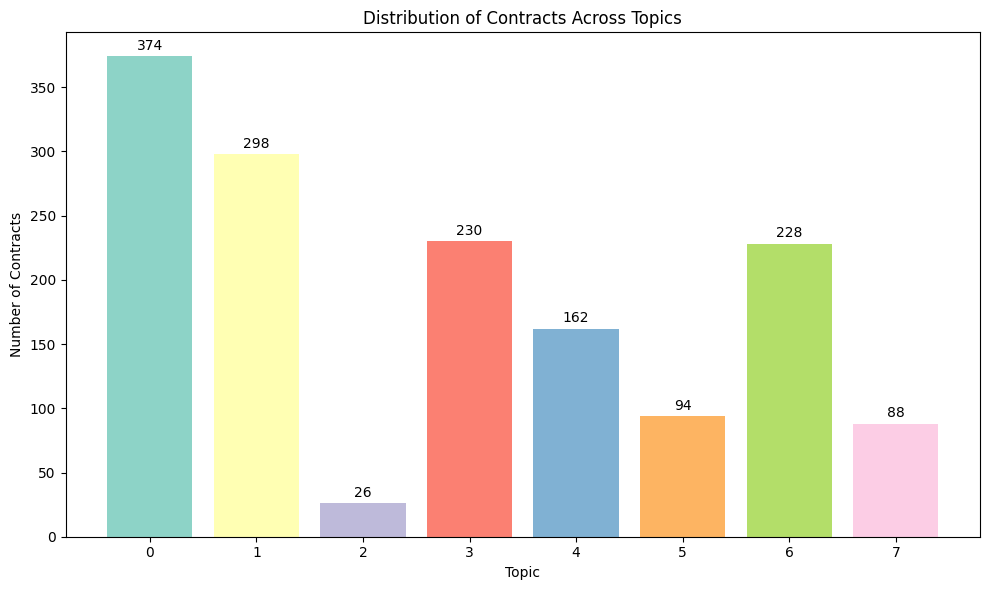

In [42]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. **Easier to interpret:**
   - **ArXiv topics are easier to interpret** than legal contract topics.
   - **Reason:** Scientific sub-disciplines have very distinct, domain-specific vocabularies — terms like "quantum", "entanglement", "convolutional", "gradient" are almost exclusively tied to a single field. Legal text, by contrast, recycles the same procedural vocabulary ("party", "agreement", "shall", "term", "payment") across nearly every contract type. This high inter-topic lexical overlap makes legal topics less crisp; the discriminating terms are often subtler (e.g., "salary" vs. "royalty" vs. "indemnify").

2. **Legal topic distribution:**
   - **Not balanced** — service agreements and confidentiality/NDA clauses tend to dominate contract corpora (they are present in almost every commercial contract), while niche topics like arbitration or real estate are underrepresented.
   - **What this indicates:** The legal_contracts dataset is drawn largely from commercial agreements (SaaS, consulting, vendor) rather than a stratified sample of all contract types. Topic models will overfit to common clause patterns and under-discover rare but legally important topics (e.g., GDPR data processing addenda, force majeure).

3. **Topic refinement suggestions:**
   - **ArXiv — Merge:** Topics "Statistical Methods & Probability" (Topic 6) and "Optimization & Control Theory" (Topic 7) — both share heavy overlap in mathematical notation words (e.g., "convergence", "bound", "estimate", "distribution") and often appear together in papers.
   - **ArXiv — Split:** "Machine Learning & Neural Networks" (Topic 0) should be split into "Deep Learning & Computer Vision" vs. "Classical ML & Ensemble Methods" — the two sub-communities use sufficiently different vocabulary that forcing them into one topic dilutes coherence.
   - **Legal — Merge:** "Termination & Breach Provisions" (Topic 4) and "Indemnification & Liability" (Topic 5) — these clauses co-occur in almost every contract and their keyword sets (e.g., "material breach", "damages", "liability", "indemnify", "terminate") overlap strongly.
   - **Legal — Split:** "Service Agreements & Deliverables" (Topic 3) should be split into "Software/SaaS Services" vs. "Professional/Consulting Services" — the former has distinct vocabulary around APIs, uptime, SLAs and the latter around milestones, statements of work, and hourly rates.

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [ ] All code exercises completed (fill all `___` placeholders)
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**
